# Финальный анализ privacy attacks

Ноутбук собирает итоговые таблицы и графики по `MIA` и `data extraction`, сохраняет их в `artifacts/analysis/` и при необходимости отправляет логи в `Comet`.

## Setup

In [1]:
!pip install -q -r requirements.txt
!pip install -q accelerate Pillow pandas tqdm einops timm comet_ml huggingface_hub
!pip install -q peft bitsandbytes trl qwen-vl-utils
%pip install -q seaborn matplotlib python-dotenv
!pip uninstall -y transformers tokenizers
!pip install -q tokenizers==0.21.0
!pip install -q transformers==4.49.0 --force-reinstall --no-deps


ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 786.2/786.2 kB 11.9 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 42.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 630.8/630.8 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 50.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 19.8 MB/s eta 0:00:00:00:0100:01
Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: tokenizers 0.22.2
Uninstalling tokenizers-0.22.2:
  Successfully uninstalled tokenizers-0.22.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3

In [ ]:
import os



In [3]:
from __future__ import annotations

import json
import os
import subprocess
import sys
from pathlib import Path

import comet_ml

import transformers
print(f"transformers version: {transformers.__version__}")
if not transformers.__version__.startswith("4.4"):
    print(f"WARNING: expected 4.4x.x, got {transformers.__version__}. Florence-2 may fail.")


def find_project_root(start: Path) -> Path | None:
    for candidate in [start, *start.parents]:
        if (candidate / 'src').exists() and (candidate / 'notebooks').exists() and (candidate / 'requirements.txt').exists():
            return candidate
    return None


def get_colab_secret(name: str) -> str | None:
    try:
        from google.colab import userdata
        return userdata.get(name)
    except Exception:
        return os.getenv(name)


IS_COLAB = 'google.colab' in sys.modules
if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT = Path('/content/drive/MyDrive/course_work2026')
    DRIVE_ROOT.mkdir(parents=True, exist_ok=True)
    repo_dir = Path('/content/course_work2026')
    if not repo_dir.exists():
        subprocess.run([
            'git', 'clone',
            get_colab_secret('COURSE_WORK2026_REPO_URL') or 'https://github.com/sk3feel/hidden-data-reproduction-multimodal.git',
            str(repo_dir),
        ], check=True)
    PROJECT_ROOT = find_project_root(repo_dir) or find_project_root(Path.cwd())
    if PROJECT_ROOT is None:
        raise RuntimeError('Could not locate project root in Colab even after cloning the repository.')
else:
    PROJECT_ROOT = find_project_root(Path.cwd())
    if PROJECT_ROOT is None:
        raise RuntimeError('Could not locate project root. Open the notebook from the repository workspace or set the working directory inside the repo.')
    DRIVE_ROOT = PROJECT_ROOT

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

if IS_COLAB:
    from src.colab_setup import setup_colab
    setup_summary, bootstrap_experiment = setup_colab(repo_url=get_colab_secret('COURSE_WORK2026_REPO_URL') or 'https://github.com/sk3feel/hidden-data-reproduction-multimodal.git')
    bootstrap_experiment.set_name('final-analysis-bootstrap')
    bootstrap_experiment.end()
    PROJECT_ROOT = Path(setup_summary['project_root'])
    sys.path.insert(0, str(PROJECT_ROOT))
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

DATA_ARTIFACTS_ROOT = PROJECT_ROOT / 'artifacts'
ARTIFACTS_ROOT = DRIVE_ROOT / 'artifacts'
MIA_DIR = ARTIFACTS_ROOT / 'privacy_attacks' / 'mia'
EXTRACTION_DIR = ARTIFACTS_ROOT / 'privacy_attacks' / 'extraction'
ANALYSIS_DIR = ARTIFACTS_ROOT / 'analysis'
FIGURES_DIR = ANALYSIS_DIR / 'figures'
TABLES_DIR = ANALYSIS_DIR / 'tables'
QUAL_DIR = ANALYSIS_DIR / 'qualitative'
for path in [ANALYSIS_DIR, FIGURES_DIR, TABLES_DIR, QUAL_DIR]:
    path.mkdir(parents=True, exist_ok=True)

FINAL_EXPERIMENT = comet_ml.Experiment(project_name=os.getenv('COMET_PROJECT_NAME') or 'qwen3-1', workspace=os.getenv('COMET_WORKSPACE') or 'scfeel')
FINAL_EXPERIMENT.set_name('final-analysis')

print({
    'project_root': str(PROJECT_ROOT),
    'drive_root': str(DRIVE_ROOT),
    'mia_dir': str(MIA_DIR),
    'extraction_dir': str(EXTRACTION_DIR),
    'analysis_dir': str(ANALYSIS_DIR),
    'is_colab': IS_COLAB,
})


Mounted at /content/drive


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


artifacts_bundle.tar.gz:   0%|          | 0.00/3.04G [00:00<?, ?B/s]

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/scfeel/qwen3-1/f411f1d2c29048aa9ce32e4aa14b150b

COMET INFO: The process of logging environment details (conda environment, git patch) is underway. Please be patient as this may take some time.
COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.
COMET WARNING: Couldn't retrieve and log Google Colab notebook content, reason: 'NoneType' object is not subscriptable
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level :

{'project_root': '/content/course_work2026', 'drive_root': '/content/drive/MyDrive/course_work2026', 'mia_dir': '/content/drive/MyDrive/course_work2026/artifacts/privacy_attacks/mia', 'extraction_dir': '/content/drive/MyDrive/course_work2026/artifacts/privacy_attacks/extraction', 'analysis_dir': '/content/drive/MyDrive/course_work2026/artifacts/analysis', 'is_colab': True}


COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.


In [4]:
from __future__ import annotations

import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from src.inference_scenarios import generate_scenario_image


sns.set_theme(style='whitegrid', context='paper')
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
})

MODEL_LABELS = {
    'florence2': 'Florence-2-base',
    'qwen2b': 'Qwen2-VL-2B',
    'qwen7b': 'Qwen2-VL-7B',
}
TRAIN_LOSS_LABELS = {
    'losses_run1': 'Florence-2',
    'losses_qwen2b': 'Qwen2-VL-2B',
    'losses_qwen7b': 'Qwen2-VL-7B',
}
MODEL_PARAMS = {
    'florence2': 230_000_000,
    'qwen2b': 2_000_000_000,
    'qwen7b': 7_000_000_000,
}
IMAGE_SCENARIO_ORDER = ['original', 'img_black', 'img_blur_20', 'img_blur_50']
IMAGE_OCR_SCENARIO_ORDER = [
    'img_black__ocr_mask__k_0',
    'img_none__ocr_mask__k_0',
]
QWEN_OCR_SCENARIO_MAP = {
    'img_black__ocr_mask__k_0': 'ocr_mask__img_black__k_0',
    'img_none__ocr_mask__k_0': 'ocr_mask__img_none__k_0',
}
COMET_DOWNLOAD_EXPERIMENT_KEYS = []
COMET_FALLBACK_EXPERIMENT_NAMES = {
    'mia-baseline-summary',
    'mia-finetuned-summary',
    'mia-epoch-curve',
    'florence2-mia-baseline',
    'qwen2b-mia-baseline',
    'qwen7b-mia-baseline',
    'florence2-mia-finetuned',
    'qwen2b-mia-finetuned',
    'qwen7b-mia-finetuned',
    'extraction-baseline',
    'florence2-extraction',
    'qwen2b-extraction-imageonly',
    'qwen2b-extraction-imageocr',
    'qwen7b-extraction-imageonly',
    'qwen7b-extraction-imageocr',
    'extraction-epoch-curve',
}


def save_figure(fig, stem: str):
    png_path = FIGURES_DIR / f'{stem}.png'
    pdf_path = FIGURES_DIR / f'{stem}.pdf'
    fig.savefig(png_path, dpi=300, bbox_inches='tight')
    fig.savefig(pdf_path, dpi=300, bbox_inches='tight')
    FINAL_EXPERIMENT.log_figure(stem, fig)
    FINAL_EXPERIMENT.log_asset(str(png_path), file_name=png_path.name)
    FINAL_EXPERIMENT.log_asset(str(pdf_path), file_name=pdf_path.name)
    return png_path, pdf_path


def save_table(df: pd.DataFrame, stem: str):
    csv_path = TABLES_DIR / f'{stem}.csv'
    tex_path = TABLES_DIR / f'{stem}.tex'
    df.to_csv(csv_path, index=False)
    df.to_latex(tex_path, index=False, float_format=lambda x: f'{x:.3f}')
    FINAL_EXPERIMENT.log_table(csv_path.name, df)
    FINAL_EXPERIMENT.log_asset(str(csv_path), file_name=csv_path.name)
    FINAL_EXPERIMENT.log_asset(str(tex_path), file_name=tex_path.name)
    return csv_path, tex_path


def iter_comet_experiments_for_download(api, workspace: str, project_name: str, experiment_keys: list[str]):
    if experiment_keys:
        for experiment_key in experiment_keys:
            try:
                yield api.get_experiment_by_key(experiment_key)
            except Exception as experiment_error:
                print({'experiment_key': experiment_key, 'error': str(experiment_error)})
        return

    try:
        experiments = api.get_experiments(workspace, project_name)
    except TypeError:
        experiments = api.get_experiments(workspace, project_name=project_name)

    for api_experiment in experiments:
        name = None
        if hasattr(api_experiment, 'get_name'):
            try:
                name = api_experiment.get_name()
            except Exception:
                name = None
        name = name or getattr(api_experiment, 'name', None)
        if name in COMET_FALLBACK_EXPERIMENT_NAMES:
            yield api_experiment


def maybe_download_csvs_from_comet(target_dir: Path, experiment_keys: list[str]):
    if any(target_dir.glob('*.csv')) or not experiment_keys:
        if any(target_dir.glob('*.csv')):
            return
    api_key = os.getenv('COMET_API_KEY') or get_colab_secret('COMET_API_KEY')
    if not api_key:
        print(f'No local CSV in {target_dir} and COMET_API_KEY is not available; skipping Comet download.')
        return
    workspace = os.getenv('COMET_WORKSPACE') or get_colab_secret('COMET_WORKSPACE') or 'scfeel'
    project_name = os.getenv('COMET_PROJECT_NAME') or get_colab_secret('COMET_PROJECT_NAME') or 'qwen3-1'
    api = comet_ml.API(api_key=api_key)
    for api_experiment in iter_comet_experiments_for_download(api, workspace, project_name, experiment_keys):
        experiment_key = getattr(api_experiment, 'key', None)
        experiment_name = getattr(api_experiment, 'name', None)
        try:
            asset_list = api_experiment.get_asset_list()
        except Exception as asset_list_error:
            print({'experiment_key': experiment_key, 'experiment_name': experiment_name, 'error': str(asset_list_error)})
            continue
        for asset in asset_list:
            file_name = asset.get('fileName') or asset.get('file_name') or asset.get('title')
            asset_id = asset.get('assetId') or asset.get('asset_id')
            if not file_name or not file_name.endswith('.csv') or not asset_id:
                continue
            destination = target_dir / file_name
            if destination.exists():
                continue
            try:
                payload = api_experiment.get_asset(asset_id, return_type='binary', stream=False)
                destination.write_bytes(payload)
            except Exception as asset_error:
                print({'experiment_key': experiment_key, 'experiment_name': experiment_name, 'file_name': file_name, 'error': str(asset_error)})


def load_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f'Missing required CSV: {path}. Put results into artifacts/privacy_attacks/ or make COMET_API_KEY available for fallback download.')
    return pd.read_csv(path)


def load_optional_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path)


def build_mia_score_df(path: Path) -> pd.DataFrame:
    df = load_csv(path).copy()
    if 'is_seen' not in df.columns and 'split' in df.columns:
        df['is_seen'] = (df['split'] == 'seen').astype(int)
    if 'coarse_type' not in df.columns:
        if 'field_type' in df.columns:
            df['coarse_type'] = df['field_type']
        else:
            df['coarse_type'] = 'OTHER'
    if 'question_id' not in df.columns:
        if 'example_id' in df.columns:
            df['question_id'] = df['example_id'].astype(str)
        else:
            df['question_id'] = [str(i) for i in range(len(df))]
    return df


def build_mia_coarse_dfs(field_auc_df: pd.DataFrame) -> dict[str, pd.DataFrame]:
    tag_map = {
        'florence2_epoch30': 'florence2',
        'qwen2b_epoch20': 'qwen2b',
        'qwen7b_epoch10': 'qwen7b',
    }
    result = {}
    for source_tag, target_tag in tag_map.items():
        subset = field_auc_df[field_auc_df['model'] == source_tag].copy()
        if subset.empty:
            result[target_tag] = pd.DataFrame(columns=['coarse_type', 'auc_confidence', 'auc_loss', 'n_examples'])
            continue
        subset['coarse_type'] = subset['field_type']
        result[target_tag] = subset
    return result


def load_jsonl(path: Path) -> list[dict]:
    rows = []
    with path.open('r', encoding='utf-8') as fh:
        for line in fh:
            if line.strip():
                rows.append(json.loads(line))
    return rows


def load_records(manifest_path: Path, split: str, limit: int | None = None) -> list[dict]:
    records = load_jsonl(manifest_path)
    if limit is not None:
        records = records[:limit]
    image_dir = manifest_path.parent / 'images' / 'original'
    normalized = []
    for idx, record in enumerate(records):
        image_name = str(record['image_path']).replace('\\', '/').split('/')[-1]
        updated = dict(record)
        updated['image_path'] = str(image_dir / image_name)
        updated['split'] = split
        updated['record_key'] = f"{split}:{record.get('example_id', 'na')}:{record.get('local_row_id', idx)}"
        normalized.append(updated)
    return normalized


maybe_download_csvs_from_comet(MIA_DIR, COMET_DOWNLOAD_EXPERIMENT_KEYS)
maybe_download_csvs_from_comet(EXTRACTION_DIR, COMET_DOWNLOAD_EXPERIMENT_KEYS)

TRAIN_RECORDS = load_records(DATA_ARTIFACTS_ROOT / 'docqa_recovery' / 'benchmark_train' / 'manifest.jsonl', split='seen', limit=800)
VALIDATION_RECORDS = load_records(DATA_ARTIFACTS_ROOT / 'docqa_recovery' / 'benchmark' / 'manifest.jsonl', split='unseen', limit=800)
RECORD_LOOKUP = {record['record_key']: record for record in TRAIN_RECORDS + VALIDATION_RECORDS}
RECORD_LOOKUP_BY_ID_SPLIT = {(str(record.get('example_id', '')), record['split']): record for record in TRAIN_RECORDS + VALIDATION_RECORDS}

MIA_BASELINE_SUMMARY = load_csv(MIA_DIR / 'baseline_mia_summary.csv')
MIA_FINETUNED_SUMMARY = load_csv(MIA_DIR / 'finetuned_mia_summary.csv')
MIA_EPOCH_CURVE = load_optional_csv(MIA_DIR / 'mia_epoch_curve.csv')
MIA_SCORE_DFS = {
    'florence2': build_mia_score_df(MIA_DIR / 'florence2_epoch30.csv'),
    'qwen2b': build_mia_score_df(MIA_DIR / 'qwen2b_epoch20.csv'),
    'qwen7b': build_mia_score_df(MIA_DIR / 'qwen7b_epoch10.csv'),
}
FIELD_TYPE_AUC_DF = load_csv(MIA_DIR / 'field_type_auc.csv')
MIA_COARSE_DFS = build_mia_coarse_dfs(FIELD_TYPE_AUC_DF)

EXTRACTION_BASELINE = load_csv(EXTRACTION_DIR / 'baseline_florence2_image_only_metrics.csv')
EXTRACTION_EPOCH_CURVE = load_optional_csv(EXTRACTION_DIR / 'extraction_epoch_curve.csv')
EXTRACTION_METRICS = {
    'florence2_image_only': load_csv(EXTRACTION_DIR / 'florence2_epoch30_image_only_metrics.csv'),
    'qwen2b_image_only': load_csv(EXTRACTION_DIR / 'qwen2b_epoch20_image_only_metrics.csv'),
    'qwen2b_image_ocr': load_csv(EXTRACTION_DIR / 'qwen2b_epoch20_image_ocr_metrics.csv'),
    'qwen7b_image_only': load_csv(EXTRACTION_DIR / 'qwen7b_epoch10_image_only_metrics.csv'),
    'qwen7b_image_ocr': load_optional_csv(EXTRACTION_DIR / 'qwen7b_epoch10_image_ocr_metrics.csv'),
}
EXTRACTION_SUCCESS = {
    'florence2_image_only': load_csv(EXTRACTION_DIR / 'florence2_epoch30_image_only_successful_examples.csv'),
    'qwen2b_image_only': load_csv(EXTRACTION_DIR / 'qwen2b_epoch20_image_only_successful_examples.csv'),
    'qwen2b_image_ocr': load_csv(EXTRACTION_DIR / 'qwen2b_epoch20_image_ocr_successful_examples.csv'),
    'qwen7b_image_only': load_csv(EXTRACTION_DIR / 'qwen7b_epoch10_image_only_successful_examples.csv'),
    'qwen7b_image_ocr': load_optional_csv(EXTRACTION_DIR / 'qwen7b_epoch10_image_ocr_successful_examples.csv'),
}
TRAIN_LOSS_DIRS = [
    DRIVE_ROOT / 'artifacts' / 'finetuning_generative',
    DATA_ARTIFACTS_ROOT / 'finetuning_generative',
]
TRAIN_LOSS_DFS = {}
for stem in TRAIN_LOSS_LABELS:
    for candidate_dir in TRAIN_LOSS_DIRS:
        candidate = candidate_dir / f'{stem}.csv'
        if candidate.exists():
            TRAIN_LOSS_DFS[stem] = load_csv(candidate)
            break

print({'mia_csv_count': len(list(MIA_DIR.glob('*.csv'))), 'extraction_csv_count': len(list(EXTRACTION_DIR.glob('*.csv'))), 'train_loss_csv_count': len(TRAIN_LOSS_DFS)})

{'mia_csv_count': 9, 'extraction_csv_count': 21, 'train_loss_csv_count': 0}


In [5]:
# LaTeX figure export helpers
from pathlib import Path
import os

LATEX_EXPORT_TAG = 'v1'
LATEX_NOTEBOOK_NAME = '24_final_analysis.ipynb'
LATEX_EXPORT_ROOT = DRIVE_ROOT / 'latex_export'
LATEX_GRAPHICS_DIR = LATEX_EXPORT_ROOT / 'graphics'
LATEX_EXPORT_ROOT.mkdir(parents=True, exist_ok=True)
os.makedirs(LATEX_GRAPHICS_DIR, exist_ok=True)
LATEX_SAVED_FIGURES = []

def _latex_figure_filename(stem: str) -> str:
    return f"{stem}_{LATEX_EXPORT_TAG}.pdf"

_original_save_figure = save_figure

def save_figure(fig, stem: str):
    result = _original_save_figure(fig, stem)
    latex_pdf_path = LATEX_GRAPHICS_DIR / _latex_figure_filename(stem)
    fig.savefig(latex_pdf_path, bbox_inches='tight', dpi=300)
    if latex_pdf_path.name not in LATEX_SAVED_FIGURES:
        LATEX_SAVED_FIGURES.append(latex_pdf_path.name)
    return result

print({'latex_export_root': str(LATEX_EXPORT_ROOT), 'latex_graphics_dir': str(LATEX_GRAPHICS_DIR), 'latex_export_tag': LATEX_EXPORT_TAG})


{'latex_export_root': '/content/drive/MyDrive/course_work2026/latex_export', 'latex_graphics_dir': '/content/drive/MyDrive/course_work2026/latex_export/graphics', 'latex_export_tag': 'v1'}


## 1. MIA графики

,model,stage,method,auc,model_label
0,florence2,baseline,confidence,0.572125,Florence-2-base
1,florence2,baseline,loss,0.513950,Florence-2-base
2,qwen2b,baseline,confidence,0.500000,Qwen2-VL-2B
3,qwen2b,baseline,loss,0.549225,Qwen2-VL-2B
4,florence2,fine-tuned,confidence,0.577788,Florence-2-base
5,florence2,fine-tuned,loss,0.992000,Florence-2-base
6,qwen2b,fine-tuned,confidence,0.500000,Qwen2-VL-2B
7,qwen2b,fine-tuned,loss,0.963775,Qwen2-VL-2B
8,qwen7b,fine-tuned,confidence,0.500000,Qwen2-VL-7B
9,qwen7b,fine-tuned,loss,0.939875,Qwen2-VL-7B


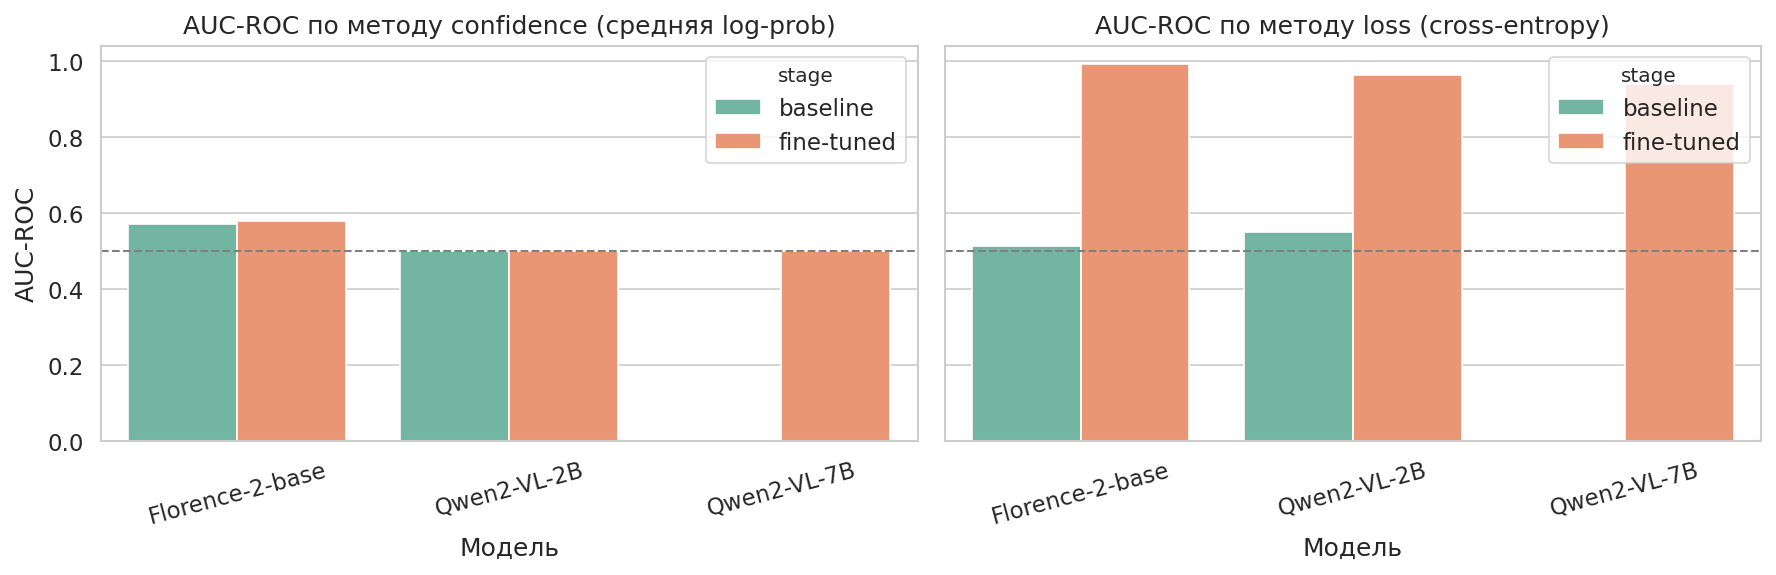

In [6]:
mia_bar_rows = []
for _, row in MIA_BASELINE_SUMMARY.iterrows():
    mia_bar_rows.append({'model': row['tag'], 'stage': 'baseline', 'method': 'confidence', 'auc': row['auc_confidence']})
    mia_bar_rows.append({'model': row['tag'], 'stage': 'baseline', 'method': 'loss', 'auc': row['auc_loss']})
for _, row in MIA_FINETUNED_SUMMARY.iterrows():
    mia_bar_rows.append({'model': row['tag'], 'stage': 'fine-tuned', 'method': 'confidence', 'auc': row['auc_confidence']})
    mia_bar_rows.append({'model': row['tag'], 'stage': 'fine-tuned', 'method': 'loss', 'auc': row['auc_loss']})
mia_bar_df = pd.DataFrame(mia_bar_rows)
mia_bar_df['model_label'] = mia_bar_df['model'].map(MODEL_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, method in zip(axes, ['confidence', 'loss']):
    plot_df = mia_bar_df[mia_bar_df['method'] == method]
    sns.barplot(data=plot_df, x='model_label', y='auc', hue='stage', ax=ax, palette='Set2')
    ax.set_title('AUC-ROC по методу ' + ('confidence (средняя log-prob)' if method == 'confidence' else 'loss (cross-entropy)'))
    ax.set_xlabel('Модель')
    ax.set_ylabel('AUC-ROC')
    ax.axhline(0.5, linestyle='--', color='gray', linewidth=1)
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
save_figure(fig, 'mia_bar_baseline_vs_finetuned')
display(mia_bar_df)

(PosixPath('/content/drive/MyDrive/course_work2026/artifacts/analysis/figures/mia_confidence_histograms.png'),
 PosixPath('/content/drive/MyDrive/course_work2026/artifacts/analysis/figures/mia_confidence_histograms.pdf'))

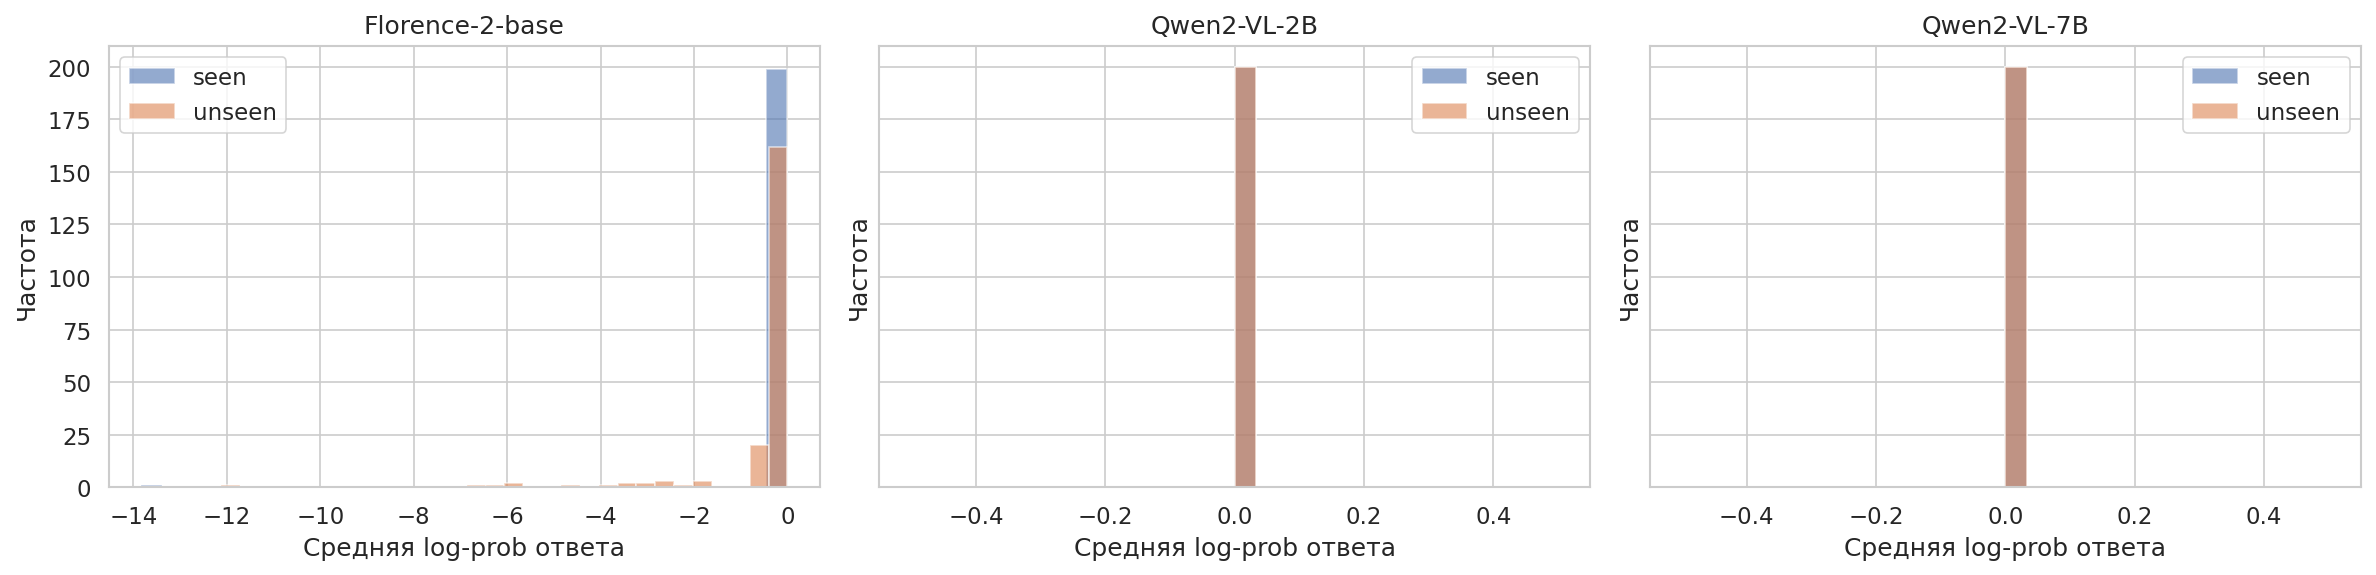

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, tag in zip(axes, ['florence2', 'qwen2b', 'qwen7b']):
    df = MIA_SCORE_DFS[tag]
    ax.hist(df.loc[df['is_seen'] == 1, 'confidence'], bins=30, alpha=0.6, label='seen')
    ax.hist(df.loc[df['is_seen'] == 0, 'confidence'], bins=30, alpha=0.6, label='unseen')
    ax.set_title(MODEL_LABELS[tag])
    ax.set_xlabel('Средняя log-prob ответа')
    ax.set_ylabel('Частота')
    ax.legend()
plt.tight_layout()
save_figure(fig, 'mia_confidence_histograms')

,model,field_type,auc_confidence,auc_loss,n_examples,coarse_type,tag,model_label
0,florence2_epoch30,AMOUNT,0.655510,0.993469,70,AMOUNT,florence2,Florence-2-base
1,florence2_epoch30,CONTACT_ADR,0.552342,1.000000,66,CONTACT_ADR,florence2,Florence-2-base
2,florence2_epoch30,DATE,0.704316,1.000000,66,DATE,florence2,Florence-2-base
3,florence2_epoch30,ID,0.678145,0.980716,66,ID,florence2,Florence-2-base
4,florence2_epoch30,ORG,0.492195,0.977961,66,ORG,florence2,Florence-2-base
5,florence2_epoch30,PERSON,0.415978,1.000000,66,PERSON,florence2,Florence-2-base
6,qwen2b_epoch20,AMOUNT,0.500000,0.946939,70,AMOUNT,qwen2b,Qwen2-VL-2B
7,qwen2b_epoch20,CONTACT_ADR,0.500000,0.976125,66,CONTACT_ADR,qwen2b,Qwen2-VL-2B
8,qwen2b_epoch20,DATE,0.500000,0.963269,66,DATE,qwen2b,Qwen2-VL-2B
9,qwen2b_epoch20,ID,0.500000,0.957759,66,ID,qwen2b,Qwen2-VL-2B


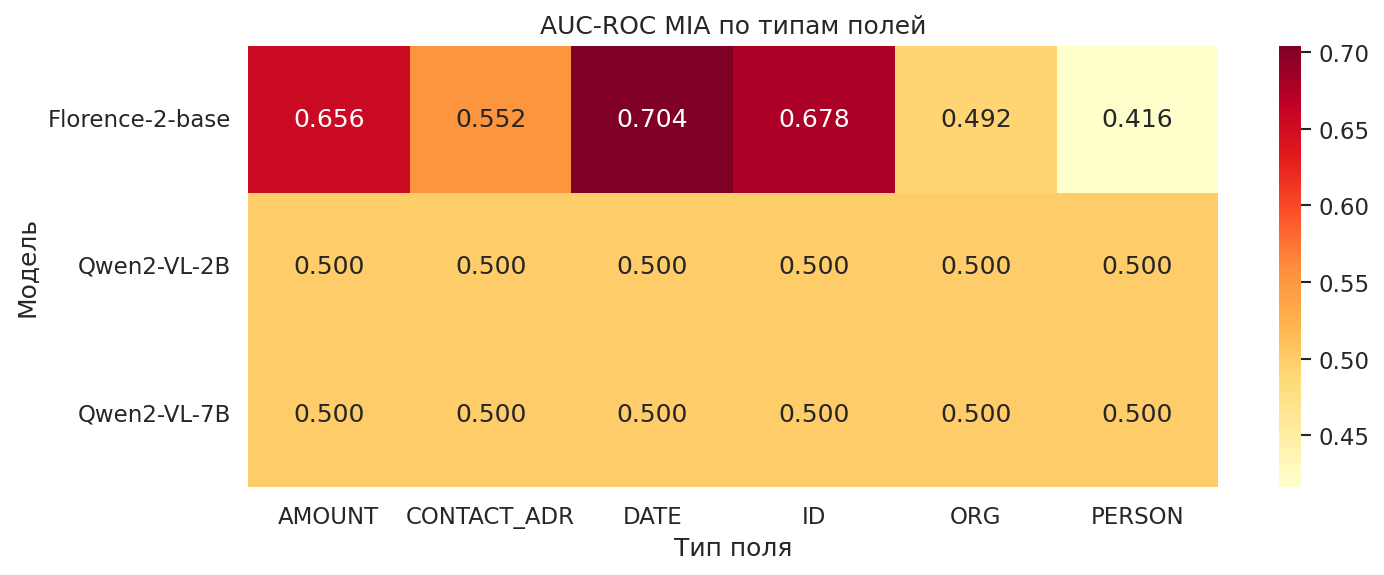

In [8]:
mia_heatmap_df = pd.concat([
    df.assign(tag=tag, model_label=MODEL_LABELS[tag])
    for tag, df in MIA_COARSE_DFS.items() if not df.empty
], ignore_index=True)
mia_heatmap = mia_heatmap_df.pivot(index='model_label', columns='coarse_type', values='auc_confidence')
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(mia_heatmap, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax)
ax.set_title('AUC-ROC MIA по типам полей')
ax.set_xlabel('Тип поля')
ax.set_ylabel('Модель')
plt.tight_layout()
save_figure(fig, 'mia_heatmap_model_fieldtype_auc')
display(mia_heatmap_df)

In [9]:
epoch_curve_df = MIA_EPOCH_CURVE.copy()
if epoch_curve_df.empty:
    print('mia_epoch_curve.csv not found; skipping epoch curve plot.')
else:
    epoch_curve_df['model_label'] = epoch_curve_df['tag'].map(MODEL_LABELS)
    fig, ax = plt.subplots(figsize=(8, 5))
    for tag, group in epoch_curve_df.groupby('tag'):
        ax.plot(group['epoch'], group['auc_confidence'], marker='o', label=MODEL_LABELS[tag])
    ax.set_title('Кривая MIA по эпохам')
    ax.set_xlabel('Эпоха')
    ax.set_ylabel('AUC-ROC')
    ax.axhline(0.5, linestyle='--', color='gray', linewidth=1)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    save_figure(fig, 'mia_epoch_curve')
    display(epoch_curve_df)

if not TRAIN_LOSS_DFS:
    print('Training loss CSV files not found; skipping train loss plot.')
else:
    train_loss_rows = []
    for stem, df in TRAIN_LOSS_DFS.items():
        temp = df.copy()
        temp['source'] = stem
        temp['model_label'] = TRAIN_LOSS_LABELS[stem]
        train_loss_rows.append(temp)
    train_loss_df = pd.concat(train_loss_rows, ignore_index=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    for stem, group in train_loss_df.groupby('source'):
        group = group.sort_values('epoch')
        ax.plot(group['epoch'], group['loss'], marker='o', label=TRAIN_LOSS_LABELS[stem])
    ax.set_title('Кривая train loss по эпохам')
    ax.set_xlabel('Эпоха')
    ax.set_ylabel('Train loss')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    save_figure(fig, 'training_loss_curves')
    display(train_loss_df)

mia_epoch_curve.csv not found; skipping epoch curve plot.
Training loss CSV files not found; skipping train loss plot.


,tag,auc_confidence,auc_loss,params,log_params,model_label
0,florence2,0.577788,0.992000,230000000,8.361728,Florence-2-base
1,qwen2b,0.500000,0.963775,2000000000,9.301030,Qwen2-VL-2B
2,qwen7b,0.500000,0.939875,7000000000,9.845098,Qwen2-VL-7B


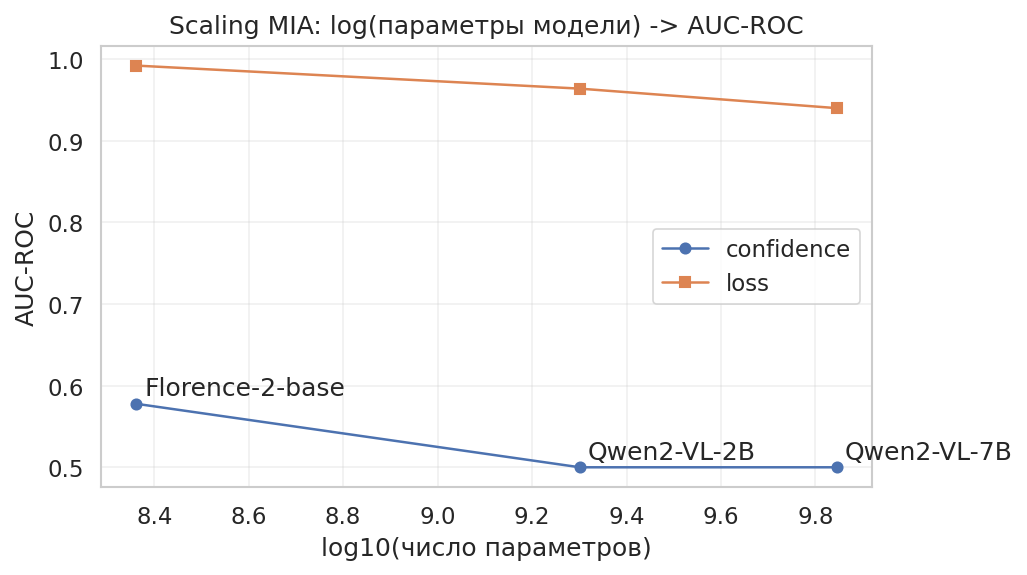

In [10]:
scaling_df = MIA_FINETUNED_SUMMARY[['tag', 'auc_confidence', 'auc_loss']].copy()
scaling_df['params'] = scaling_df['tag'].map(MODEL_PARAMS)
scaling_df['log_params'] = np.log10(scaling_df['params'])
scaling_df['model_label'] = scaling_df['tag'].map(MODEL_LABELS)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(scaling_df['log_params'], scaling_df['auc_confidence'], marker='o', label='confidence')
ax.plot(scaling_df['log_params'], scaling_df['auc_loss'], marker='s', label='loss')
for _, row in scaling_df.iterrows():
    ax.annotate(row['model_label'], (row['log_params'], row['auc_confidence']), xytext=(4, 4), textcoords='offset points')
ax.set_title('Scaling MIA: log(параметры модели) -> AUC-ROC')
ax.set_xlabel('log10(число параметров)')
ax.set_ylabel('AUC-ROC')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
save_figure(fig, 'mia_scaling_auc')
display(scaling_df)

## 2. Extraction графики

,split,scenario,coarse_type,n_examples,exact_match,token_f1,random_em,random_f1,corrected_em,corrected_f1,tag,model_label
0,seen,img_black,ALL,200,0.160,0.284155,0.01425,0.034906,0.14575,0.249249,florence2,Florence-2-base
1,seen,img_blur_20,ALL,200,0.165,0.290040,0.01425,0.034906,0.15075,0.255134,florence2,Florence-2-base
2,seen,img_blur_50,ALL,200,0.170,0.295595,0.01425,0.034906,0.15575,0.260689,florence2,Florence-2-base
3,seen,original,ALL,200,0.980,0.982500,0.01425,0.034906,0.96575,0.947594,florence2,Florence-2-base
4,seen,img_black,ALL,200,0.610,0.659755,0.01425,0.034906,0.59575,0.624850,qwen2b,Qwen2-VL-2B
5,seen,img_blur_20,ALL,200,0.615,0.657999,0.01425,0.034906,0.60075,0.623093,qwen2b,Qwen2-VL-2B
6,seen,img_blur_50,ALL,200,0.615,0.659316,0.01425,0.034906,0.60075,0.624411,qwen2b,Qwen2-VL-2B
7,seen,original,ALL,200,0.960,0.970641,0.01425,0.034906,0.94575,0.935735,qwen2b,Qwen2-VL-2B
8,seen,img_black,ALL,200,0.560,0.629224,0.01425,0.034906,0.54575,0.594318,qwen7b,Qwen2-VL-7B
9,seen,img_blur_20,ALL,200,0.560,0.622589,0.01425,0.034906,0.54575,0.587683,qwen7b,Qwen2-VL-7B


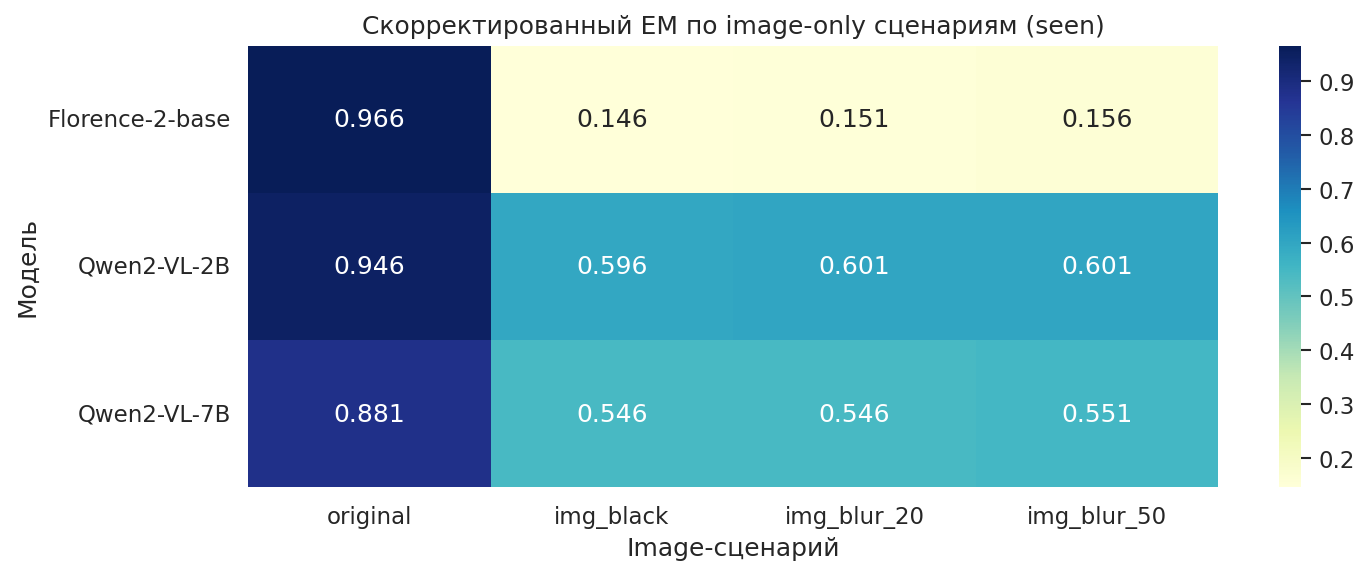

In [11]:
image_only_metrics = []
for key in ['florence2_image_only', 'qwen2b_image_only', 'qwen7b_image_only']:
    tag = key.split('_')[0]
    df = EXTRACTION_METRICS[key]
    subset = df[(df['split'] == 'seen') & (df['coarse_type'] == 'ALL')].copy()
    subset['tag'] = tag
    subset['model_label'] = MODEL_LABELS[tag]
    image_only_metrics.append(subset)
image_only_metrics_df = pd.concat(image_only_metrics, ignore_index=True)
heatmap_df = image_only_metrics_df.pivot(index='model_label', columns='scenario', values='corrected_em')[IMAGE_SCENARIO_ORDER]

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax)
ax.set_title('Скорректированный EM по image-only сценариям (seen)')
ax.set_xlabel('Image-сценарий')
ax.set_ylabel('Модель')
plt.tight_layout()
save_figure(fig, 'extraction_heatmap_image_only_seen')
display(image_only_metrics_df)

,split,scenario,coarse_type,n_examples,exact_match,token_f1,random_em,random_f1,corrected_em,corrected_f1,tag,model_label
0,seen,img_black__ocr_mask__k_0,ALL,200,0.040,0.128294,0.01425,0.034906,0.02575,0.093389,qwen2b,Qwen2-VL-2B
1,seen,img_none__ocr_mask__k_0,ALL,200,0.335,0.402714,0.01425,0.034906,0.32075,0.367809,qwen2b,Qwen2-VL-2B


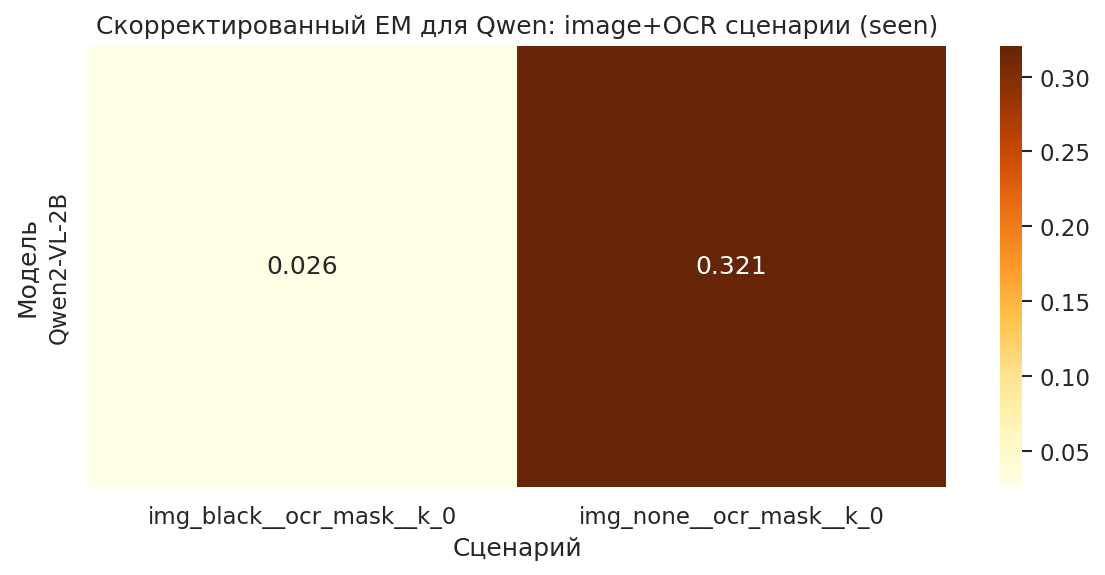

In [12]:
image_ocr_metrics = []
for key in ['qwen2b_image_ocr', 'qwen7b_image_ocr']:
    tag = key.split('_')[0]
    df = EXTRACTION_METRICS[key]
    if df.empty:
        continue
    subset = df[(df['split'] == 'seen') & (df['coarse_type'] == 'ALL')].copy()
    subset['tag'] = tag
    subset['model_label'] = MODEL_LABELS[tag]
    image_ocr_metrics.append(subset)
if not image_ocr_metrics:
    print('No image+OCR extraction metrics found; skipping OCR heatmap.')
else:
    image_ocr_metrics_df = pd.concat(image_ocr_metrics, ignore_index=True)
    heatmap_df = image_ocr_metrics_df.pivot(index='model_label', columns='scenario', values='corrected_em').reindex(columns=IMAGE_OCR_SCENARIO_ORDER)
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap='YlOrBr', ax=ax)
    ax.set_title('Скорректированный EM для Qwen: image+OCR сценарии (seen)')
    ax.set_xlabel('Сценарий')
    ax.set_ylabel('Модель')
    plt.tight_layout()
    save_figure(fig, 'extraction_heatmap_image_ocr_seen')
    display(image_ocr_metrics_df)

,split,scenario,coarse_type,n_examples,exact_match,token_f1,random_em,random_f1,corrected_em,corrected_f1,tag,model_label
0,seen,img_black,AMOUNT,35,0.200000,0.347619,0.007143,0.028143,0.192857,0.319476,florence2,Florence-2-base
1,seen,img_black,CONTACT_ADR,33,0.272727,0.373737,0.037879,0.040909,0.234848,0.332828,florence2,Florence-2-base
2,seen,img_black,DATE,33,0.151515,0.269841,0.004545,0.035245,0.146970,0.234596,florence2,Florence-2-base
3,seen,img_black,ID,33,0.060606,0.113131,0.015152,0.016667,0.045455,0.096465,florence2,Florence-2-base
4,seen,img_black,ORG,33,0.151515,0.363709,0.019697,0.073098,0.131818,0.290611,florence2,Florence-2-base
5,seen,img_black,PERSON,33,0.121212,0.233045,0.001515,0.015783,0.119697,0.217262,florence2,Florence-2-base
6,seen,img_black,AMOUNT,35,0.600000,0.633333,0.007143,0.028143,0.592857,0.605190,qwen2b,Qwen2-VL-2B
7,seen,img_black,CONTACT_ADR,33,0.575758,0.644930,0.037879,0.040909,0.537879,0.604021,qwen2b,Qwen2-VL-2B
8,seen,img_black,DATE,33,0.484848,0.563709,0.004545,0.035245,0.480303,0.528463,qwen2b,Qwen2-VL-2B
9,seen,img_black,ID,33,0.606061,0.618182,0.015152,0.016667,0.590909,0.601515,qwen2b,Qwen2-VL-2B


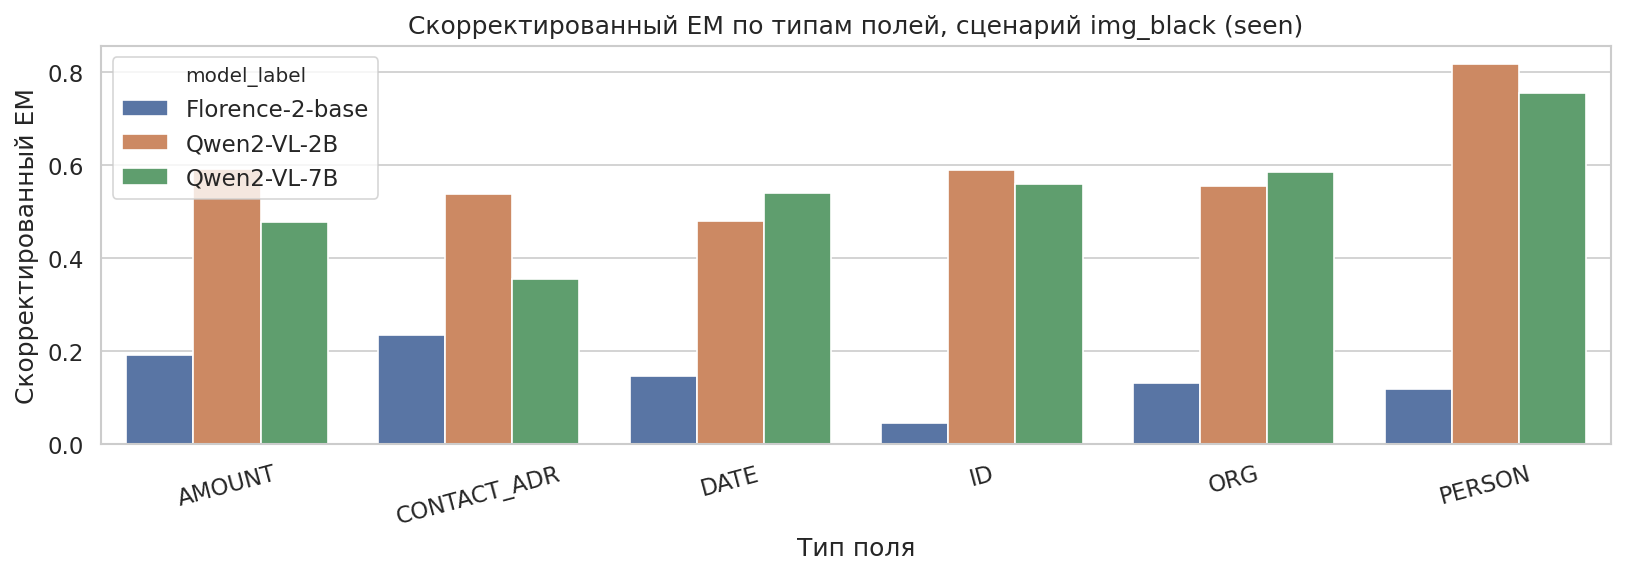

In [13]:
field_type_rows = []
for key in ['florence2_image_only', 'qwen2b_image_only', 'qwen7b_image_only']:
    tag = key.split('_')[0]
    df = EXTRACTION_METRICS[key]
    subset = df[(df['split'] == 'seen') & (df['scenario'] == 'img_black') & (df['coarse_type'] != 'ALL')].copy()
    subset['tag'] = tag
    subset['model_label'] = MODEL_LABELS[tag]
    field_type_rows.append(subset)
field_type_df = pd.concat(field_type_rows, ignore_index=True)

fig, ax = plt.subplots(figsize=(11, 4))
sns.barplot(data=field_type_df, x='coarse_type', y='corrected_em', hue='model_label', ax=ax)
ax.set_title('Скорректированный EM по типам полей, сценарий img_black (seen)')
ax.set_xlabel('Тип поля')
ax.set_ylabel('Скорректированный EM')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
save_figure(fig, 'extraction_bar_fieldtype_img_black')
display(field_type_df)

,split,scenario,coarse_type,n_examples,exact_match,token_f1,random_em,random_f1,corrected_em,corrected_f1,sigma,tag,model_label
0,seen,img_blur_20,ALL,200,0.165,0.290040,0.01425,0.034906,0.15075,0.255134,20,florence2,Florence-2-base
1,seen,img_blur_50,ALL,200,0.170,0.295595,0.01425,0.034906,0.15575,0.260689,50,florence2,Florence-2-base
2,seen,img_blur_20,ALL,200,0.615,0.657999,0.01425,0.034906,0.60075,0.623093,20,qwen2b,Qwen2-VL-2B
3,seen,img_blur_50,ALL,200,0.615,0.659316,0.01425,0.034906,0.60075,0.624411,50,qwen2b,Qwen2-VL-2B
4,seen,img_blur_20,ALL,200,0.560,0.622589,0.01425,0.034906,0.54575,0.587683,20,qwen7b,Qwen2-VL-7B
5,seen,img_blur_50,ALL,200,0.565,0.624994,0.01425,0.034906,0.55075,0.590088,50,qwen7b,Qwen2-VL-7B


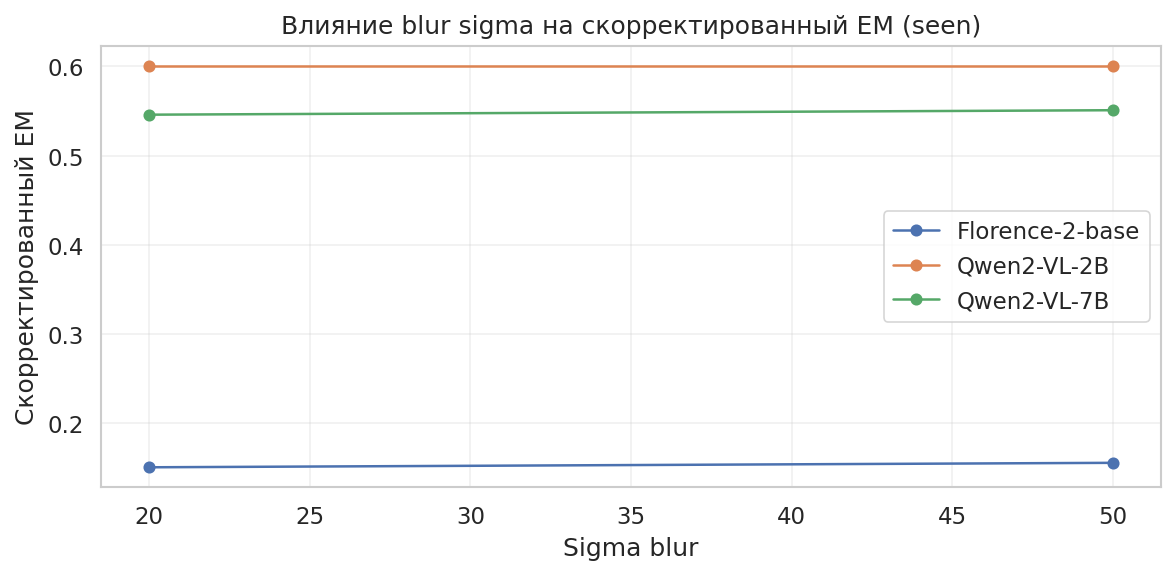

In [14]:
blur_rows = []
for key in ['florence2_image_only', 'qwen2b_image_only', 'qwen7b_image_only']:
    tag = key.split('_')[0]
    df = EXTRACTION_METRICS[key]
    subset = df[(df['split'] == 'seen') & (df['coarse_type'] == 'ALL') & (df['scenario'].isin(['img_blur_20', 'img_blur_50']))].copy()
    subset['sigma'] = subset['scenario'].str.extract(r'(\d+)').astype(int)
    subset['tag'] = tag
    subset['model_label'] = MODEL_LABELS[tag]
    blur_rows.append(subset)
blur_df = pd.concat(blur_rows, ignore_index=True)

fig, ax = plt.subplots(figsize=(8, 4))
for tag, group in blur_df.groupby('tag'):
    group = group.sort_values('sigma')
    ax.plot(group['sigma'], group['corrected_em'], marker='o', label=MODEL_LABELS[tag])
ax.set_title('Влияние blur sigma на скорректированный EM (seen)')
ax.set_xlabel('Sigma blur')
ax.set_ylabel('Скорректированный EM')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
save_figure(fig, 'extraction_blur_sigma_curve')
display(blur_df)

,tag,model_label,mode,mean_corrected_em
0,qwen2b,Qwen2-VL-2B,image_only,0.68575
1,qwen2b,Qwen2-VL-2B,image+OCR,0.17325
2,qwen7b,Qwen2-VL-7B,image_only,0.63075


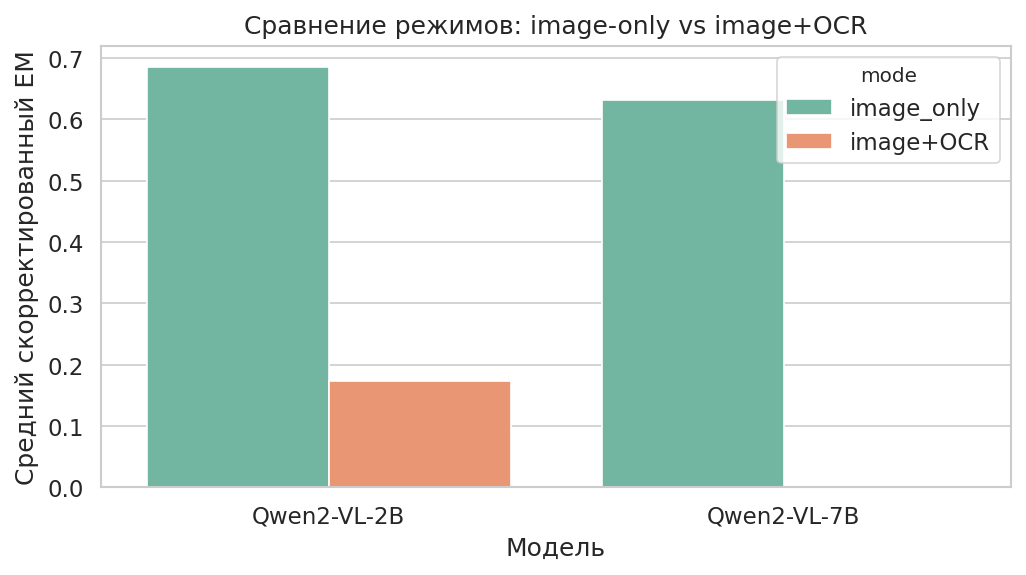

In [15]:
mode_compare_rows = []
for tag in ['qwen2b', 'qwen7b']:
    image_only_df = EXTRACTION_METRICS[f'{tag}_image_only']
    image_ocr_df = EXTRACTION_METRICS[f'{tag}_image_ocr']
    mode_compare_rows.append({'tag': tag, 'model_label': MODEL_LABELS[tag], 'mode': 'image_only', 'mean_corrected_em': image_only_df[(image_only_df['split'] == 'seen') & (image_only_df['coarse_type'] == 'ALL')]['corrected_em'].mean()})
    if not image_ocr_df.empty:
        mode_compare_rows.append({'tag': tag, 'model_label': MODEL_LABELS[tag], 'mode': 'image+OCR', 'mean_corrected_em': image_ocr_df[(image_ocr_df['split'] == 'seen') & (image_ocr_df['coarse_type'] == 'ALL')]['corrected_em'].mean()})
mode_compare_df = pd.DataFrame(mode_compare_rows)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=mode_compare_df, x='model_label', y='mean_corrected_em', hue='mode', ax=ax, palette='Set2')
ax.set_title('Сравнение режимов: image-only vs image+OCR')
ax.set_xlabel('Модель')
ax.set_ylabel('Средний скорректированный EM')
plt.tight_layout()
save_figure(fig, 'extraction_mode_compare')
display(mode_compare_df)

In [16]:
epoch_curve_df = EXTRACTION_EPOCH_CURVE.copy()
if epoch_curve_df.empty:
    print('extraction_epoch_curve.csv not found; skipping epoch curve plot.')
else:
    epoch_curve_df['model_label'] = epoch_curve_df['tag'].map(MODEL_LABELS)
    fig, ax = plt.subplots(figsize=(8, 5))
    for tag, group in epoch_curve_df.groupby('tag'):
        ax.plot(group['epoch'], group['corrected_em'], marker='o', label=MODEL_LABELS[tag])
    ax.set_title('Кривая extraction по эпохам (img_black, seen)')
    ax.set_xlabel('Эпоха')
    ax.set_ylabel('Скорректированный EM')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    save_figure(fig, 'extraction_epoch_curve')
    display(epoch_curve_df)

extraction_epoch_curve.csv not found; skipping epoch curve plot.


,tag,model_label,mia_auc,extraction_corrected_em
0,florence2,Florence-2-base,0.992000,0.14575
1,qwen2b,Qwen2-VL-2B,0.963775,0.59575
2,qwen7b,Qwen2-VL-7B,0.939875,0.54575


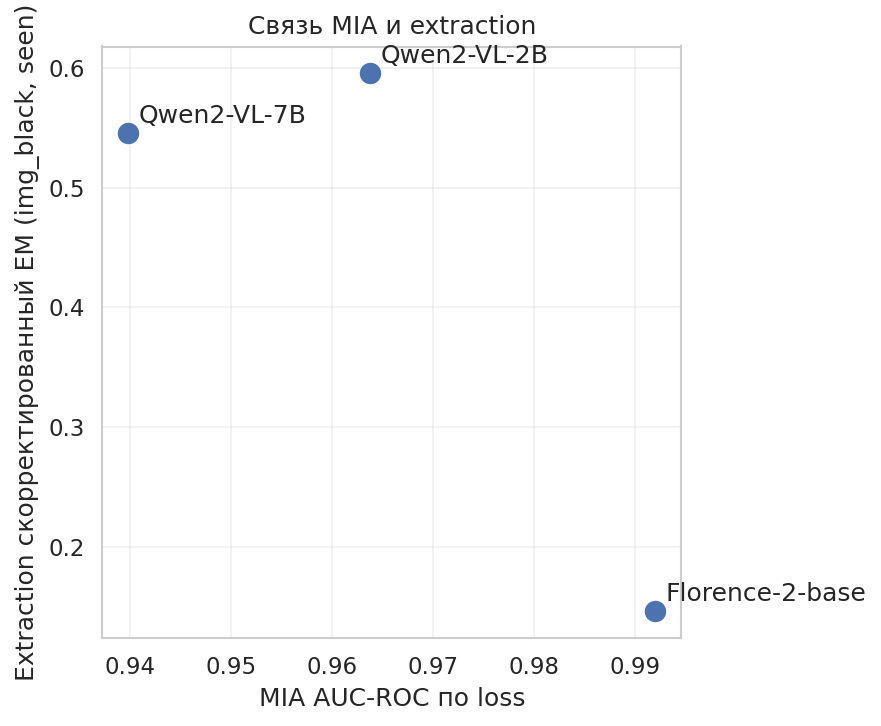

In [17]:
scatter_rows = []
for tag in ['florence2', 'qwen2b', 'qwen7b']:
    mia_auc = float(MIA_FINETUNED_SUMMARY.loc[MIA_FINETUNED_SUMMARY['tag'] == tag, 'auc_loss'].iloc[0])
    extraction_em = float(EXTRACTION_METRICS[f'{tag}_image_only'].loc[(EXTRACTION_METRICS[f'{tag}_image_only']['split'] == 'seen') & (EXTRACTION_METRICS[f'{tag}_image_only']['scenario'] == 'img_black') & (EXTRACTION_METRICS[f'{tag}_image_only']['coarse_type'] == 'ALL'), 'corrected_em'].iloc[0])
    scatter_rows.append({'tag': tag, 'model_label': MODEL_LABELS[tag], 'mia_auc': mia_auc, 'extraction_corrected_em': extraction_em})
scatter_df = pd.DataFrame(scatter_rows)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(scatter_df['mia_auc'], scatter_df['extraction_corrected_em'], s=90)
for _, row in scatter_df.iterrows():
    ax.annotate(row['model_label'], (row['mia_auc'], row['extraction_corrected_em']), xytext=(5, 5), textcoords='offset points')
ax.set_title('Связь MIA и extraction')
ax.set_xlabel('MIA AUC-ROC по loss')
ax.set_ylabel('Extraction скорректированный EM (img_black, seen)')
ax.grid(alpha=0.3)
plt.tight_layout()
save_figure(fig, 'mia_vs_extraction_scatter')
display(scatter_df)

## 3. Качественный анализ

In [18]:
success_examples_df = pd.concat([
    df.assign(source=name)
    for name, df in EXTRACTION_SUCCESS.items() if not df.empty
], ignore_index=True).head(10).copy()
save_table(success_examples_df, 'table_qual_success_examples')
display(success_examples_df)

,example_id,split,scenario,prediction,question,answer,answers,coarse_type,ocr_text_used,ocr_source,exact_match,token_f1,random_em,random_f1,corrected_em,corrected_f1,normalized_prediction,normalized_answer,source
0,d643464768e7f73a585bbc78d50ac70c,seen,img_black,10,For how many years did Christopher Jahn work f...,10,"['10', 'nearly 10 years', '10 years']",AMOUNT,NaN,NaN,1.0,1.0,0.0,0.066667,1.0,0.933333,10,10,florence2_image_only
1,d643464768e7f73a585bbc78d50ac70c,seen,img_blur_20,10,For how many years did Christopher Jahn work f...,10,"['10', 'nearly 10 years', '10 years']",AMOUNT,NaN,NaN,1.0,1.0,0.0,0.066667,1.0,0.933333,10,10,florence2_image_only
2,d643464768e7f73a585bbc78d50ac70c,seen,img_blur_50,10,For how many years did Christopher Jahn work f...,10,"['10', 'nearly 10 years', '10 years']",AMOUNT,NaN,NaN,1.0,1.0,0.0,0.066667,1.0,0.933333,10,10,florence2_image_only
3,d407aa0cd7ca49fb9dd26b66304a12fd,seen,img_blur_20,2,How many environmental options are listed?,2,['2'],AMOUNT,NaN,NaN,1.0,1.0,0.0,0.000000,1.0,1.000000,2,2,florence2_image_only
4,d407aa0cd7ca49fb9dd26b66304a12fd,seen,img_blur_50,2,How many environmental options are listed?,2,['2'],AMOUNT,NaN,NaN,1.0,1.0,0.0,0.000000,1.0,1.000000,2,2,florence2_image_only
5,3c831ed40e70ddea61c93cd0caff3354,seen,img_black,"10,050",What is the Grant Balance Payable 12/31/86 by ...,"10,050","['10,050']",AMOUNT,NaN,NaN,1.0,1.0,0.0,0.025000,1.0,0.975000,10 050,10 050,florence2_image_only
6,3c831ed40e70ddea61c93cd0caff3354,seen,img_blur_20,"10,050",What is the Grant Balance Payable 12/31/86 by ...,"10,050","['10,050']",AMOUNT,NaN,NaN,1.0,1.0,0.0,0.025000,1.0,0.975000,10 050,10 050,florence2_image_only
7,3c831ed40e70ddea61c93cd0caff3354,seen,img_blur_50,"10,050",What is the Grant Balance Payable 12/31/86 by ...,"10,050","['10,050']",AMOUNT,NaN,NaN,1.0,1.0,0.0,0.025000,1.0,0.975000,10 050,10 050,florence2_image_only
8,a07ddd3476f10f715205d0ad18b7099f,seen,img_black,"10,925",What is the Grant Balance Payable 12/31/87 by ...,"10,925","['10,925']",AMOUNT,NaN,NaN,1.0,1.0,0.0,0.025000,1.0,0.975000,10 925,10 925,florence2_image_only
9,a07ddd3476f10f715205d0ad18b7099f,seen,img_blur_20,"10,925",What is the Grant Balance Payable 12/31/87 by ...,"10,925","['10,925']",AMOUNT,NaN,NaN,1.0,1.0,0.0,0.025000,1.0,0.975000,10 925,10 925,florence2_image_only


COMET INFO: Trying to log a figure that is exceeding allowed SVG file size limit (2436614 > 1048576). Falling back to PNG format.


(PosixPath('/content/drive/MyDrive/course_work2026/artifacts/analysis/figures/qualitative_successful_extractions.png'),
 PosixPath('/content/drive/MyDrive/course_work2026/artifacts/analysis/figures/qualitative_successful_extractions.pdf'))

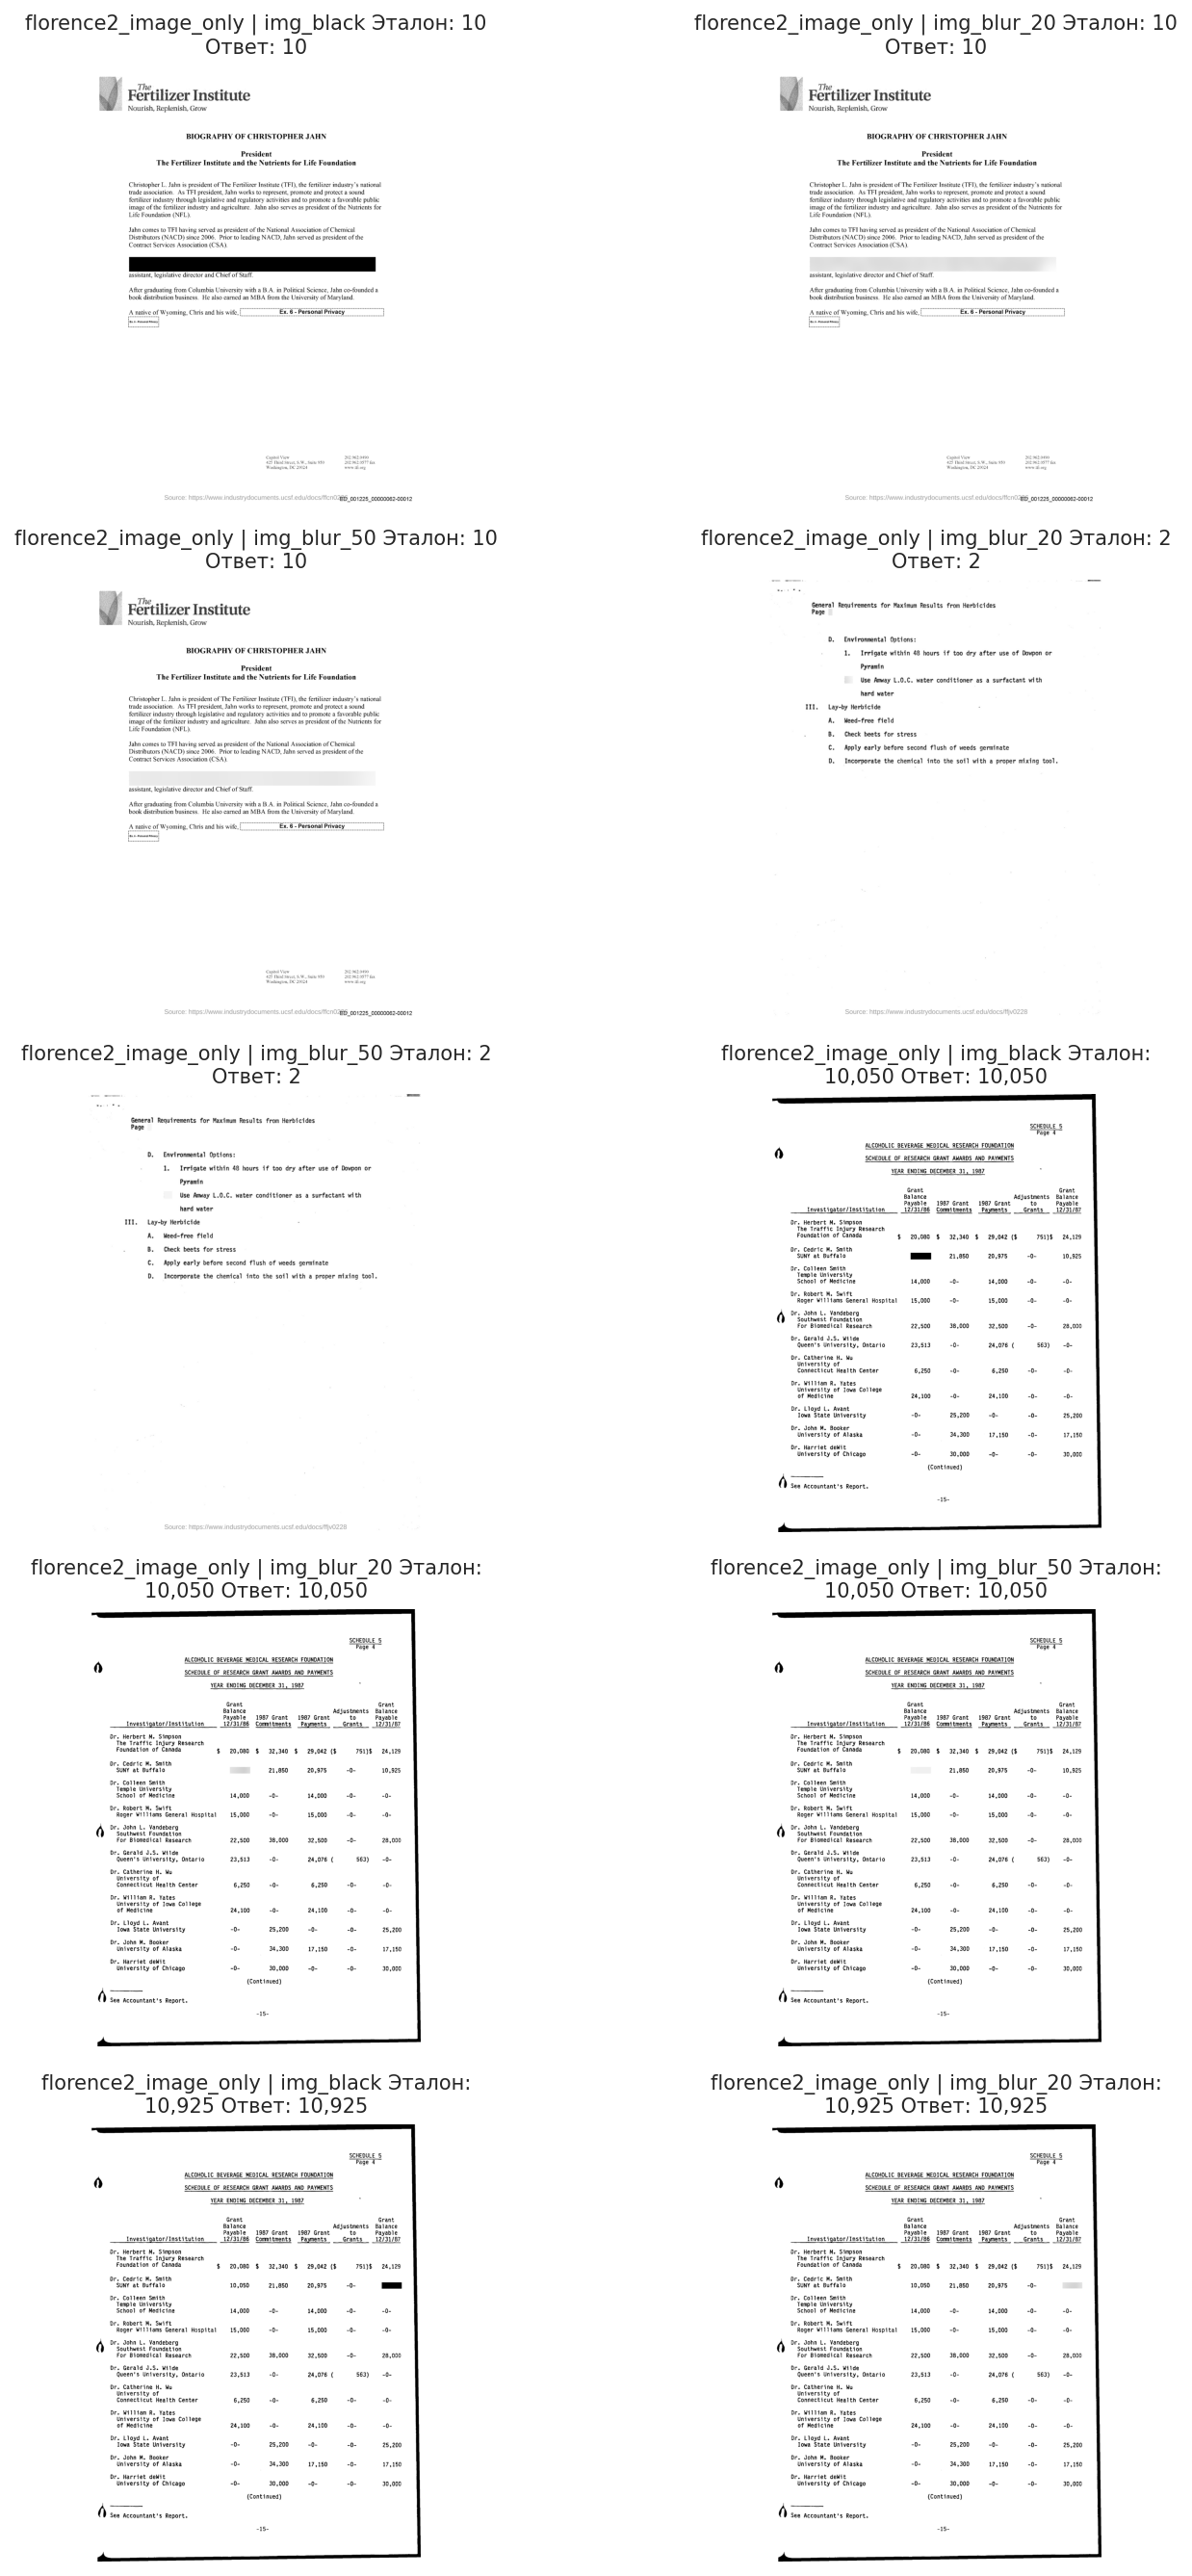

In [19]:
fig, axes = plt.subplots(5, 2, figsize=(12, 18))
axes = axes.flatten()
for ax, (_, row) in zip(axes, success_examples_df.iterrows()):
    record = None
    if 'record_key' in row and pd.notna(row['record_key']):
        record = RECORD_LOOKUP.get(row['record_key'])
    if record is None:
        record = RECORD_LOOKUP_BY_ID_SPLIT.get((str(row.get('example_id', '')), row.get('split', '')))
    if record is None:
        ax.axis('off')
        missing_title = f"{row['source']} | {row['scenario']}\nRecord not found for example_id={row.get('example_id', 'na')}"
        ax.set_title(textwrap.fill(missing_title, 45), fontsize=10)
        continue
    scenario = QWEN_OCR_SCENARIO_MAP.get(row['scenario'], row['scenario'])
    image = generate_scenario_image(record, scenario)
    ax.imshow(image)
    ax.axis('off')
    gold_value = row['answer'] if 'answer' in row else row.get('gold_answers', '')
    title = f"{row['source']} | {row['scenario']}\nЭталон: {str(gold_value)[:40]}\nОтвет: {str(row['prediction'])[:40]}"
    ax.set_title(textwrap.fill(title, 45), fontsize=10)
for ax in axes[len(success_examples_df):]:
    ax.axis('off')
plt.tight_layout()
save_figure(fig, 'qualitative_successful_extractions')

In [20]:
gap_rows = []
for tag, df in MIA_SCORE_DFS.items():
    unseen_mean = df.loc[df['is_seen'] == 0, 'confidence'].mean()
    seen_df = df.loc[df['is_seen'] == 1].copy()
    seen_df['confidence_gap'] = seen_df['confidence'] - unseen_mean
    seen_df['tag'] = tag
    gap_rows.append(seen_df)
confidence_gap_df = pd.concat(gap_rows, ignore_index=True).sort_values('confidence_gap', ascending=False).head(5).copy()
confidence_gap_df['model_label'] = confidence_gap_df['tag'].map(MODEL_LABELS)
save_table(confidence_gap_df, 'table_qual_confidence_gap_examples')
display(confidence_gap_df[['model_label', 'question_id', 'coarse_type', 'confidence', 'confidence_gap', 'loss']])

,model_label,question_id,coarse_type,confidence,confidence_gap,loss
197,Florence-2-base,dfe77a9e45169b84d6b31d0f4a0b79b1,PERSON,0.0,0.481699,0.000007
194,Florence-2-base,bb6d3a4dea0652c68205286d71b7238b,PERSON,0.0,0.481699,0.000042
29,Florence-2-base,297348ff0456d652941a6725c7542390,AMOUNT,0.0,0.481699,0.000008
27,Florence-2-base,5c8ac9e0ec7b6cee7ac132018bae6cb7,AMOUNT,0.0,0.481699,0.000329
24,Florence-2-base,92f8d8117382a130ae700e128452d02d,AMOUNT,0.0,0.481699,0.000004


In [21]:
patterns = []
best_mia = MIA_FINETUNED_SUMMARY.sort_values('auc_confidence', ascending=False).iloc[0]
patterns.append(f"Максимальный MIA риск по confidence показывает {MODEL_LABELS[best_mia['tag']]}: AUC={best_mia['auc_confidence']:.3f}.")
best_extraction = scatter_df.sort_values('extraction_corrected_em', ascending=False).iloc[0]
patterns.append(f"Наилучший extraction в сценарии img_black показывает {best_extraction['model_label']}: corrected EM={best_extraction['extraction_corrected_em']:.3f}.")
best_field = field_type_df.groupby('coarse_type', as_index=False)['corrected_em'].mean().sort_values('corrected_em', ascending=False).iloc[0]
patterns.append(f"Самый уязвимый coarse type в среднем по моделям на img_black: {best_field['coarse_type']} (corrected EM={best_field['corrected_em']:.3f}).")
best_ocr = image_ocr_metrics_df.groupby('scenario', as_index=False)['corrected_em'].mean().sort_values('corrected_em', ascending=False).iloc[0]
patterns.append(f"Самый сильный image+OCR сценарий в среднем по Qwen: {best_ocr['scenario']} (corrected EM={best_ocr['corrected_em']:.3f}).")
patterns_df = pd.DataFrame({'pattern': patterns})
save_table(patterns_df, 'table_qual_patterns')
display(patterns_df)

,pattern
0,Максимальный MIA риск по confidence показывает...
1,Наилучший extraction в сценарии img_black пока...
2,Самый уязвимый coarse type в среднем по моделя...
3,Самый сильный image+OCR сценарий в среднем по ...


## 4. Сводные таблицы

In [22]:
table1 = mia_bar_df.pivot_table(index=['model_label', 'stage'], columns='method', values='auc').reset_index()
table2 = mia_heatmap_df[['model_label', 'coarse_type', 'auc_confidence', 'auc_loss', 'n_examples']].sort_values(['model_label', 'coarse_type']).reset_index(drop=True)
table3 = image_only_metrics_df[['model_label', 'split', 'scenario', 'corrected_em', 'corrected_f1', 'exact_match', 'token_f1']].sort_values(['model_label', 'split', 'scenario']).reset_index(drop=True)
table4 = image_ocr_metrics_df[['model_label', 'split', 'scenario', 'corrected_em', 'corrected_f1', 'exact_match', 'token_f1']].sort_values(['model_label', 'split', 'scenario']).reset_index(drop=True)
table5 = field_type_df[['model_label', 'coarse_type', 'corrected_em', 'corrected_f1', 'exact_match', 'token_f1']].sort_values(['coarse_type', 'model_label']).reset_index(drop=True)
table6 = scatter_df.merge(scaling_df[['model_label', 'params']], on='model_label', how='left').sort_values('params').reset_index(drop=True)

for idx, df in enumerate([table1, table2, table3, table4, table5, table6], start=1):
    save_table(df, f'table_{idx:02d}')

display(table1)
display(table2.head())
display(table3.head())
display(table4.head())
display(table5.head())
display(table6)

method,model_label,stage,confidence,loss
0,Florence-2-base,baseline,0.572125,0.513950
1,Florence-2-base,fine-tuned,0.577788,0.992000
2,Qwen2-VL-2B,baseline,0.500000,0.549225
3,Qwen2-VL-2B,fine-tuned,0.500000,0.963775
4,Qwen2-VL-7B,fine-tuned,0.500000,0.939875


,model_label,coarse_type,auc_confidence,auc_loss,n_examples
0,Florence-2-base,AMOUNT,0.655510,0.993469,70
1,Florence-2-base,CONTACT_ADR,0.552342,1.000000,66
2,Florence-2-base,DATE,0.704316,1.000000,66
3,Florence-2-base,ID,0.678145,0.980716,66
4,Florence-2-base,ORG,0.492195,0.977961,66


,model_label,split,scenario,corrected_em,corrected_f1,exact_match,token_f1
0,Florence-2-base,seen,img_black,0.14575,0.249249,0.160,0.284155
1,Florence-2-base,seen,img_blur_20,0.15075,0.255134,0.165,0.290040
2,Florence-2-base,seen,img_blur_50,0.15575,0.260689,0.170,0.295595
3,Florence-2-base,seen,original,0.96575,0.947594,0.980,0.982500
4,Qwen2-VL-2B,seen,img_black,0.59575,0.624850,0.610,0.659755


,model_label,split,scenario,corrected_em,corrected_f1,exact_match,token_f1
0,Qwen2-VL-2B,seen,img_black__ocr_mask__k_0,0.02575,0.093389,0.040,0.128294
1,Qwen2-VL-2B,seen,img_none__ocr_mask__k_0,0.32075,0.367809,0.335,0.402714


,model_label,coarse_type,corrected_em,corrected_f1,exact_match,token_f1
0,Florence-2-base,AMOUNT,0.192857,0.319476,0.200000,0.347619
1,Qwen2-VL-2B,AMOUNT,0.592857,0.605190,0.600000,0.633333
2,Qwen2-VL-7B,AMOUNT,0.478571,0.538524,0.485714,0.566667
3,Florence-2-base,CONTACT_ADR,0.234848,0.332828,0.272727,0.373737
4,Qwen2-VL-2B,CONTACT_ADR,0.537879,0.604021,0.575758,0.644930


,tag,model_label,mia_auc,extraction_corrected_em,params
0,florence2,Florence-2-base,0.992000,0.14575,230000000
1,qwen2b,Qwen2-VL-2B,0.963775,0.59575,2000000000
2,qwen7b,Qwen2-VL-7B,0.939875,0.54575,7000000000


In [23]:
analysis_paths = sorted([str(path) for path in FIGURES_DIR.glob('*')] + [str(path) for path in TABLES_DIR.glob('*')])
analysis_manifest = pd.DataFrame({'artifact_path': analysis_paths})
analysis_manifest_csv = ANALYSIS_DIR / 'analysis_manifest.csv'
analysis_manifest.to_csv(analysis_manifest_csv, index=False)
FINAL_EXPERIMENT.log_asset(str(analysis_manifest_csv), file_name=analysis_manifest_csv.name)
display(analysis_manifest)
FINAL_EXPERIMENT.end()

,artifact_path
0,/content/drive/MyDrive/course_work2026/artifac...
1,/content/drive/MyDrive/course_work2026/artifac...
2,/content/drive/MyDrive/course_work2026/artifac...
3,/content/drive/MyDrive/course_work2026/artifac...
4,/content/drive/MyDrive/course_work2026/artifac...
5,/content/drive/MyDrive/course_work2026/artifac...
6,/content/drive/MyDrive/course_work2026/artifac...
7,/content/drive/MyDrive/course_work2026/artifac...
8,/content/drive/MyDrive/course_work2026/artifac...
9,/content/drive/MyDrive/course_work2026/artifac...


COMET WARNING: Couldn't retrieve and log Google Colab notebook content, reason: 'NoneType' object is not subscriptable
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : final-analysis
COMET INFO:     url                   : https://www.comet.com/scfeel/qwen3-1/aa87acb2ae934c78af82ae8c23477af8
COMET INFO:   Others:
COMET INFO:     Name         : final-analysis
COMET INFO:     notebook_url : https://colab.research.google.com/notebook#24_final_analysis-jvsc-e800ce86-9465-4621-8ab2-4294852c8381f882fa72-95b7-4a52-a78e-46ca9610c26e.ipynb
COMET INFO:   Uploads:
COMET INFO:     asset               : 41 (3.47 MB)
COMET INFO:     dataframe           : 9 (8.11 KB)
COMET INFO:     environment details : 1
COMET 

In [24]:
# Export for LaTeX
import os
from pathlib import Path

LATEX_EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

def _md_table(df: pd.DataFrame | None, columns=None) -> str:
    if df is None:
        return '_Not available._'
    temp = df.copy()
    if columns is not None:
        temp = temp[columns].copy()
    if temp.empty:
        return '_Empty table._'
    for col in temp.columns:
        temp[col] = temp[col].map(lambda x: '' if pd.isna(x) else x)
    return temp.to_markdown(index=False)


def _replace_markdown_section(path: Path, section_key: str, content: str) -> None:
    start = f'<!-- BEGIN: {section_key} -->'
    end = f'<!-- END: {section_key} -->'
    block = f"{start}\n{content.strip()}\n{end}\n"
    if path.exists():
        text = path.read_text(encoding='utf-8')
    else:
        text = ''
    if start in text and end in text:
        prefix, rest = text.split(start, 1)
        _, suffix = rest.split(end, 1)
        new_text = prefix.rstrip()
        if new_text:
            new_text += '\n\n'
        new_text += block
        if suffix.strip():
            new_text += '\n' + suffix.lstrip()
    else:
        new_text = text.rstrip()
        if new_text:
            new_text += '\n\n'
        new_text += block
    path.write_text(new_text, encoding='utf-8')


def _collect_metric_rows(df: pd.DataFrame | None, table_name: str, graph_name: str) -> list[dict]:
    if df is None or df.empty:
        return []
    numeric_cols = [col for col in df.columns if pd.api.types.is_numeric_dtype(df[col])]
    id_cols = [col for col in df.columns if col not in numeric_cols]
    rows = []
    for idx, row in df.iterrows():
        id_parts = []
        for col in id_cols:
            value = row[col]
            if pd.isna(value) or value == '':
                continue
            id_parts.append(f"{col}={value}")
        prefix = ' | '.join(id_parts) if id_parts else f'row={idx}'
        for col in numeric_cols:
            value = row[col]
            if pd.isna(value):
                continue
            rows.append({
                'Metric': f"{table_name}: {prefix} -> {col}",
                'Value': value,
                'Linked Graph': graph_name,
            })
    return rows


def _figure_name(stem: str) -> str:
    return f"{stem}_{LATEX_EXPORT_TAG}.pdf"


hist_rows = []
for tag, df in MIA_SCORE_DFS.items():
    for split_value, split_name in [(1, 'seen'), (0, 'unseen')]:
        series = df.loc[df['is_seen'] == split_value, 'confidence'].dropna()
        if series.empty:
            continue
        hist_rows.append({
            'tag': tag,
            'model_label': MODEL_LABELS[tag],
            'split': split_name,
            'n': int(series.shape[0]),
            'min_confidence': float(series.min()),
            'max_confidence': float(series.max()),
            'mean_confidence': float(series.mean()),
            'std_confidence': float(series.std(ddof=1)) if series.shape[0] > 1 else 0.0,
        })
hist_summary_df = pd.DataFrame(hist_rows)

figure_specs = [
    {
        'stem': 'mia_bar_baseline_vs_finetuned',
        'source': f"{LATEX_NOTEBOOK_NAME}, MIA comparison cell",
        'description': 'Bar charts of baseline and fine-tuned MIA AUC-ROC for confidence and loss.',
        'x': 'Model',
        'y': 'AUC-ROC',
        'series': 'stage = baseline, fine-tuned; panels = confidence, loss',
        'key_df': mia_bar_df,
    },
    {
        'stem': 'mia_confidence_histograms',
        'source': f"{LATEX_NOTEBOOK_NAME}, confidence histogram cell",
        'description': 'Confidence histograms for seen and unseen examples, faceted by model.',
        'x': 'Average answer log-probability',
        'y': 'Frequency',
        'series': 'seen, unseen; one panel per model',
        'key_df': hist_summary_df,
    },
    {
        'stem': 'mia_heatmap_model_fieldtype_auc',
        'source': f"{LATEX_NOTEBOOK_NAME}, field-type MIA heatmap cell",
        'description': 'Heatmap of MIA AUC by model and coarse field type.',
        'x': 'Coarse field type',
        'y': 'Model',
        'series': 'heatmap values = auc_confidence',
        'key_df': mia_heatmap_df[['model_label', 'coarse_type', 'auc_confidence', 'auc_loss', 'n_examples']] if 'mia_heatmap_df' in globals() else None,
    },
    {
        'stem': 'mia_epoch_curve',
        'source': f"{LATEX_NOTEBOOK_NAME}, MIA epoch-curve cell",
        'description': 'Epoch curve for MIA AUC.',
        'x': 'Epoch',
        'y': 'AUC-ROC',
        'series': 'one line per model',
        'key_df': MIA_EPOCH_CURVE if 'MIA_EPOCH_CURVE' in globals() and not MIA_EPOCH_CURVE.empty else None,
    },
    {
        'stem': 'training_loss_curves',
        'source': f"{LATEX_NOTEBOOK_NAME}, train-loss curve cell",
        'description': 'Training loss curves by epoch.',
        'x': 'Epoch',
        'y': 'Train loss',
        'series': 'one line per training run',
        'key_df': train_loss_df if 'train_loss_df' in globals() and not train_loss_df.empty else None,
    },
    {
        'stem': 'mia_scaling_auc',
        'source': f"{LATEX_NOTEBOOK_NAME}, scaling plot cell",
        'description': 'Scaling plot of model size versus MIA AUC.',
        'x': 'log10(number of parameters)',
        'y': 'AUC-ROC',
        'series': 'confidence, loss',
        'key_df': scaling_df,
    },
    {
        'stem': 'extraction_heatmap_image_only_seen',
        'source': f"{LATEX_NOTEBOOK_NAME}, image-only extraction heatmap cell",
        'description': 'Heatmap of corrected EM for seen image-only extraction scenarios.',
        'x': 'Image scenario',
        'y': 'Model',
        'series': 'heatmap values = corrected_em',
        'key_df': image_only_metrics_df[['model_label', 'split', 'scenario', 'corrected_em', 'corrected_f1', 'exact_match', 'token_f1']],
    },
    {
        'stem': 'extraction_heatmap_image_ocr_seen',
        'source': f"{LATEX_NOTEBOOK_NAME}, image+OCR extraction heatmap cell",
        'description': 'Heatmap of corrected EM for seen image+OCR extraction scenarios.',
        'x': 'Scenario',
        'y': 'Model',
        'series': 'heatmap values = corrected_em',
        'key_df': image_ocr_metrics_df[['model_label', 'split', 'scenario', 'corrected_em', 'corrected_f1', 'exact_match', 'token_f1']] if 'image_ocr_metrics_df' in globals() else None,
    },
    {
        'stem': 'extraction_bar_fieldtype_img_black',
        'source': f"{LATEX_NOTEBOOK_NAME}, field-type extraction barplot cell",
        'description': 'Bar plot of corrected EM by coarse field type for img_black.',
        'x': 'Coarse field type',
        'y': 'Corrected EM',
        'series': 'one bar group per model',
        'key_df': field_type_df[['model_label', 'coarse_type', 'corrected_em', 'corrected_f1', 'exact_match', 'token_f1']],
    },
    {
        'stem': 'extraction_blur_sigma_curve',
        'source': f"{LATEX_NOTEBOOK_NAME}, blur robustness cell",
        'description': 'Corrected EM as a function of blur sigma.',
        'x': 'Blur sigma',
        'y': 'Corrected EM',
        'series': 'one line per model',
        'key_df': blur_df[['model_label', 'scenario', 'sigma', 'corrected_em', 'corrected_f1']],
    },
    {
        'stem': 'extraction_mode_compare',
        'source': f"{LATEX_NOTEBOOK_NAME}, mode comparison cell",
        'description': 'Comparison of image-only and image+OCR extraction modes.',
        'x': 'Model',
        'y': 'Mean corrected EM',
        'series': 'image_only, image+OCR',
        'key_df': mode_compare_df,
    },
    {
        'stem': 'extraction_epoch_curve',
        'source': f"{LATEX_NOTEBOOK_NAME}, extraction epoch-curve cell",
        'description': 'Epoch curve for extraction performance on img_black.',
        'x': 'Epoch',
        'y': 'Corrected EM',
        'series': 'one line per model',
        'key_df': EXTRACTION_EPOCH_CURVE if 'EXTRACTION_EPOCH_CURVE' in globals() and not EXTRACTION_EPOCH_CURVE.empty else None,
    },
    {
        'stem': 'mia_vs_extraction_scatter',
        'source': f"{LATEX_NOTEBOOK_NAME}, MIA-versus-extraction cell",
        'description': 'Scatter plot of MIA loss AUC versus extraction corrected EM.',
        'x': 'MIA loss AUC-ROC',
        'y': 'Extraction corrected EM (img_black, seen)',
        'series': 'one point per model',
        'key_df': scatter_df,
    },
    {
        'stem': 'qualitative_successful_extractions',
        'source': f"{LATEX_NOTEBOOK_NAME}, qualitative examples cell",
        'description': 'Grid of successful qualitative extraction examples.',
        'x': 'None',
        'y': 'None',
        'series': 'image grid',
        'key_df': success_examples_df[['example_id', 'split', 'scenario', 'prediction', 'answer', 'source']] if 'success_examples_df' in globals() else None,
    },
]

metric_rows = []
table_exports = [
    ('MIA bar data', mia_bar_df, _figure_name('mia_bar_baseline_vs_finetuned')),
    ('MIA confidence histogram summary', hist_summary_df, _figure_name('mia_confidence_histograms')),
    ('MIA field-type heatmap data', mia_heatmap_df[['model_label', 'coarse_type', 'auc_confidence', 'auc_loss', 'n_examples']] if 'mia_heatmap_df' in globals() else None, _figure_name('mia_heatmap_model_fieldtype_auc')),
    ('MIA scaling data', scaling_df, _figure_name('mia_scaling_auc')),
    ('Extraction image-only data', image_only_metrics_df[['model_label', 'split', 'scenario', 'corrected_em', 'corrected_f1', 'exact_match', 'token_f1']], _figure_name('extraction_heatmap_image_only_seen')),
    ('Extraction image+OCR data', image_ocr_metrics_df[['model_label', 'split', 'scenario', 'corrected_em', 'corrected_f1', 'exact_match', 'token_f1']] if 'image_ocr_metrics_df' in globals() else None, _figure_name('extraction_heatmap_image_ocr_seen')),
    ('Extraction field-type data', field_type_df[['model_label', 'coarse_type', 'corrected_em', 'corrected_f1', 'exact_match', 'token_f1']], _figure_name('extraction_bar_fieldtype_img_black')),
    ('Extraction blur robustness data', blur_df[['model_label', 'scenario', 'sigma', 'corrected_em', 'corrected_f1']], _figure_name('extraction_blur_sigma_curve')),
    ('Extraction mode comparison data', mode_compare_df, _figure_name('extraction_mode_compare')),
    ('MIA vs extraction scatter data', scatter_df, _figure_name('mia_vs_extraction_scatter')),
    ('Qualitative success examples', success_examples_df[['example_id', 'split', 'scenario', 'prediction', 'answer', 'source']] if 'success_examples_df' in globals() else None, _figure_name('qualitative_successful_extractions')),
    ('Confidence gap examples', confidence_gap_df[['model_label', 'question_id', 'coarse_type', 'confidence', 'confidence_gap', 'loss']] if 'confidence_gap_df' in globals() else None, 'none'),
]
if 'train_loss_df' in globals() and not train_loss_df.empty:
    table_exports.append(('Training loss data', train_loss_df, _figure_name('training_loss_curves')))
if 'MIA_EPOCH_CURVE' in globals() and not MIA_EPOCH_CURVE.empty:
    table_exports.append(('MIA epoch curve data', MIA_EPOCH_CURVE, _figure_name('mia_epoch_curve')))
if 'EXTRACTION_EPOCH_CURVE' in globals() and not EXTRACTION_EPOCH_CURVE.empty:
    table_exports.append(('Extraction epoch curve data', EXTRACTION_EPOCH_CURVE, _figure_name('extraction_epoch_curve')))

for table_name, df, graph_name in table_exports:
    metric_rows.extend(_collect_metric_rows(df, table_name, graph_name))
metric_df = pd.DataFrame(metric_rows)

results_lines = [f"## Exported metrics: {LATEX_NOTEBOOK_NAME}", '']
if metric_df.empty:
    results_lines.append('_No metric rows were exported._')
else:
    results_lines.append(_md_table(metric_df))
for table_name, df, graph_name in table_exports:
    results_lines.extend(['', f"### {table_name}", f"Related graph: `{graph_name}`", _md_table(df)])

registry_lines = [f"## Image registry: {LATEX_NOTEBOOK_NAME}", '']
for spec in figure_specs:
    latex_filename = _figure_name(spec['stem'])
    latex_path = LATEX_GRAPHICS_DIR / latex_filename
    if not latex_path.exists():
        continue
    registry_lines.extend([
        f"### {latex_filename}",
        f"- Source: {spec['source']}",
        f"- Description: {spec['description']}",
        f"- Axes: X = {spec['x']}, Y = {spec['y']}",
        f"- Series: {spec['series']}",
        '- Key values:',
        _md_table(spec['key_df']),
        f"- LaTeX: `\\includegraphics[width=0.9\\textwidth]{{graphics/{latex_filename}}}`",
        '',
    ])

results_path = LATEX_EXPORT_ROOT / 'extracted_results.md'
registry_path = LATEX_EXPORT_ROOT / 'image_registry.md'
_replace_markdown_section(results_path, f'latex-export-{LATEX_NOTEBOOK_NAME}', '\n'.join(results_lines))
_replace_markdown_section(registry_path, f'image-registry-{LATEX_NOTEBOOK_NAME}', '\n'.join(registry_lines))

summary_files = sorted(path.name for path in LATEX_GRAPHICS_DIR.glob(f'*_{LATEX_EXPORT_TAG}.pdf'))
print({'notebook': LATEX_NOTEBOOK_NAME, 'latex_graphics_saved': len(summary_files), 'files': summary_files})


{'notebook': '24_final_analysis.ipynb', 'latex_graphics_saved': 11, 'files': ['extraction_bar_fieldtype_img_black_v1.pdf', 'extraction_blur_sigma_curve_v1.pdf', 'extraction_heatmap_image_ocr_seen_v1.pdf', 'extraction_heatmap_image_only_seen_v1.pdf', 'extraction_mode_compare_v1.pdf', 'mia_bar_baseline_vs_finetuned_v1.pdf', 'mia_confidence_histograms_v1.pdf', 'mia_heatmap_model_fieldtype_auc_v1.pdf', 'mia_scaling_auc_v1.pdf', 'mia_vs_extraction_scatter_v1.pdf', 'qualitative_successful_extractions_v1.pdf']}
